## cleaning the sierrileone data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
import pandas as pd
file="../data/sierraleone-bumbuna.csv"

df = pd.read_csv(file)

In [3]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000       0.000

In [4]:
import pandas as pd
import os

# === 1. Load the dataset ===
input_path = "../data/sierraleone-bumbuna.csv"   # Source file
output_path = "../cleaned/sierraleone-cleaned.csv"  # Destination file

# Read the CSV file
df = pd.read_csv(input_path)

# === 2. Drop the 'Comments' column if it exists ===
if 'Comments' in df.columns:
    df = df.drop(columns=['Comments'])

# === 3. Keep only rows where Cleaning == 1 ===
if 'Cleaning' in df.columns:
    df = df[df['Cleaning'] == 1]
else:
    raise KeyError("The dataset doesn't have a 'Cleaning' column.")

# === 4. Keep only rows where irradiance values are non-negative ===
irradiance_vars = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']

# Filter condition (only rows with all irradiance values ≥ 0)
df = df[(df[irradiance_vars] >= 0).all(axis=1)]

# === 5. Make sure the output directory exists ===
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# === 6. Save the cleaned data ===
df.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"Remaining rows: {len(df)}")

✅ Cleaned dataset saved to: ../cleaned/sierraleone-cleaned.csv
Remaining rows: 492


In [5]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
               GHI         DNI         DHI       ModA        ModB        Tamb  \
count   492.000000  492.000000  492.000000  492.00000  492.000000  492.000000   
mean    292.284350  139.549390  210.194309  279.49248  283.471341   24.797764   
std     172.143731  173.858601  103.051652  162.82199  161.498446    2.266361   
min      11.200000    0.000000   11.900000   14.80000   19.700000   15.100000   
25%     174.700000    1.400000  133.000000  163.82500  170.650000   23.500000   
50%     256.800000   53.250000  192.200000  242.60000  253.450000   24.700000   
75%     377.200000  233.100000  273.175000  368.92500  367.875000   26.125000   
max    1027.000000  736.800000  553.100000  906.00000  892.000000   34.500000   

               RH          WS      WSgust     WSstdev          WD     WDstdev  \
count  492.000000  492.000000  492.000000  492.000000  492.000000  492.000000   
mean    86.021748    0.610163    1.074390    0.300610  102.197561   

## checking irradiance distribution

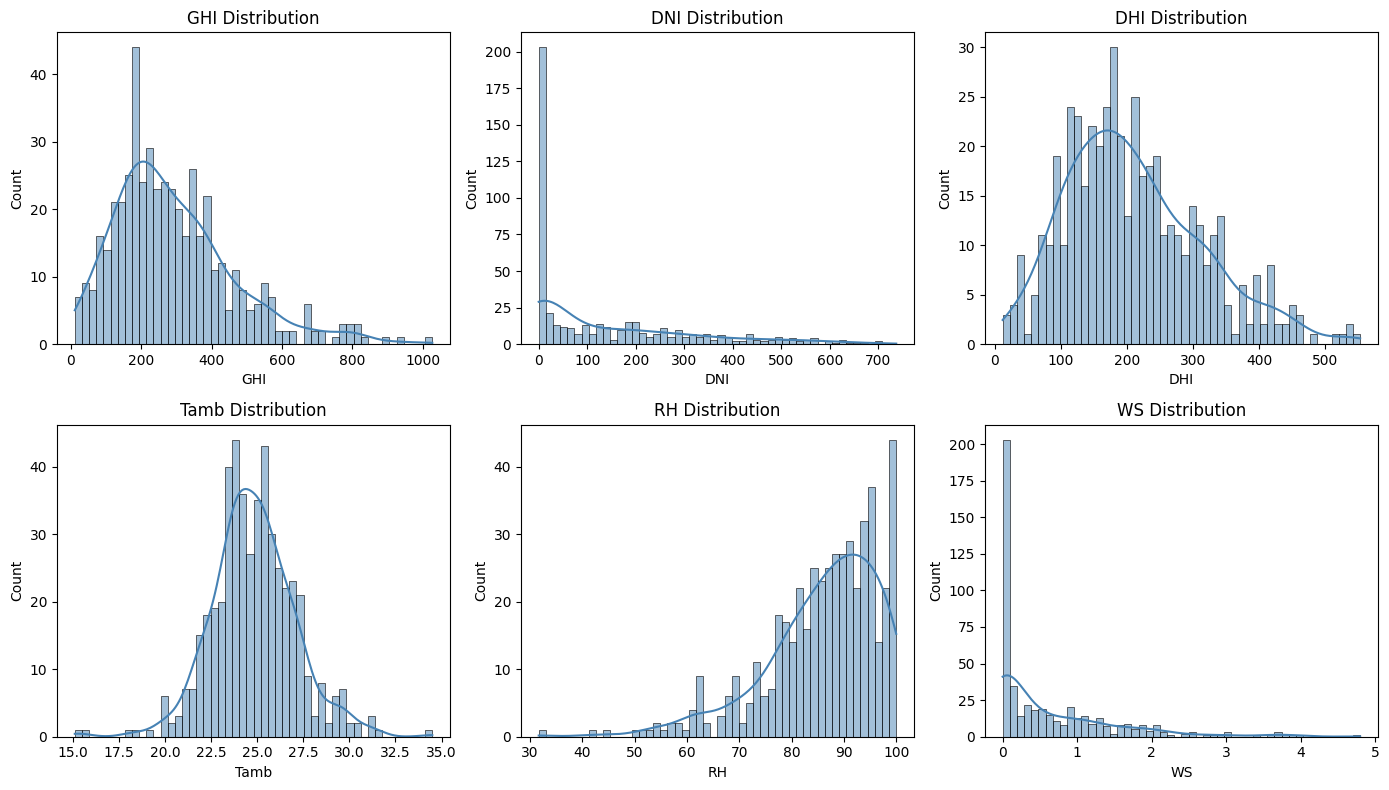

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../filtered/sierraleone-filtered.csv") 

# Choose key variables for visualization (you can modify this list)
cols_to_plot = ["GHI", "DNI", "DHI", "Tamb", "RH", "WS"]

# Plot settings
plt.figure(figsize=(14, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color="steelblue")
    plt.title(f"{col} Distribution", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


## checking the time of the day where rradiance variables are high 

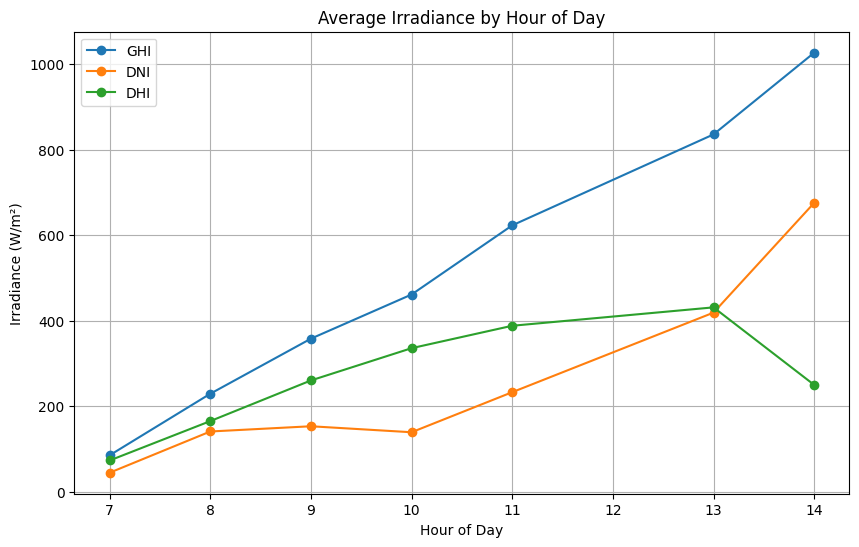

In [7]:
import pandas as pd
import matplotlib.pyplot as plt



# Convert timestamp to datetime and extract hour
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

# Compute average irradiance per hour
hourly_mean = df.groupby('Hour')[['GHI', 'DNI', 'DHI']].mean()

# Plot
hourly_mean.plot(kind='line', figsize=(10,6), marker='o')
plt.title("Average Irradiance by Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.xlabel("Hour of Day")
plt.grid(True)
plt.show()

✅ Cleaned dataset shape: (444, 18)

☀️ Average Irradiance Values (Cleaned Dataset):
GHI: 267.76 W/m²
DNI: 113.19 W/m²
DHI: 207.04 W/m²

📁 Saved summary averages to: ../cleaned/sierraleone-irradiance-summary.csv


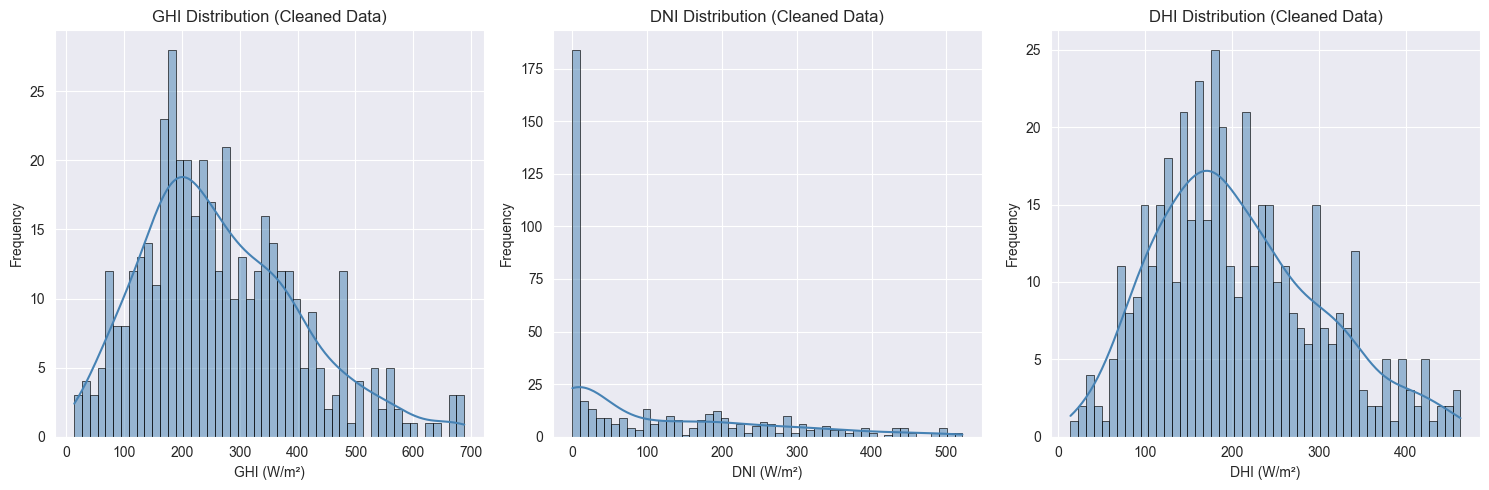

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Step 1: Load the cleaned dataset ===
input_path = "../cleaned/sierraleone-cleaned.csv"  # change this for each country
df = pd.read_csv(input_path)

# === Step 2: Convert Timestamp to datetime (if not already) ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# === Step 3: Select irradiance columns ===
irradiance_cols = ['GHI', 'DNI', 'DHI']

# === Step 4: Double-check no negative values remain ===
df[irradiance_cols] = df[irradiance_cols].clip(lower=0)

# === Step 5: Remove zeros (keep only daylight observations) ===
daylight_df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)].copy()

# === Step 6: Remove outliers using IQR ===
for col in irradiance_cols:
    Q1 = daylight_df[col].quantile(0.25)
    Q3 = daylight_df[col].quantile(0.75)
    IQR = Q3 - Q1
    daylight_df = daylight_df[
        (daylight_df[col] >= Q1 - 1.5 * IQR) &
        (daylight_df[col] <= Q3 + 1.5 * IQR)
    ]

print(f"✅ Cleaned dataset shape: {daylight_df.shape}")

# === Step 7: Compute average irradiance values ===
mean_values = daylight_df[irradiance_cols].mean()
print("\n☀️ Average Irradiance Values (Cleaned Dataset):")
for col, val in mean_values.items():
    print(f"{col}: {val:.2f} W/m²")

# === Optional: Save the averages to a summary file ===
summary_path = "../cleaned/sierraleone-irradiance-summary.csv"
pd.DataFrame(mean_values, columns=['Average (W/m²)']).to_csv(summary_path)
print(f"\n📁 Saved summary averages to: {summary_path}")

# === Step 8: Plot histograms ===
sns.set_style('darkgrid')
plt.figure(figsize=(15, 5))

for i, col in enumerate(irradiance_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(daylight_df[col], bins=50, kde=True, color='steelblue', edgecolor='black')
    plt.title(f'{col} Distribution (Cleaned Data)')
    plt.xlabel(f'{col} (W/m²)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


## computing daily total GHI


📊 Daily Irradiance Summary:
               GHI
count   264.000000
mean    544.711742
std     349.712931
min      11.200000
25%     306.250000
50%     474.800000
75%     726.675000
max    2033.900000


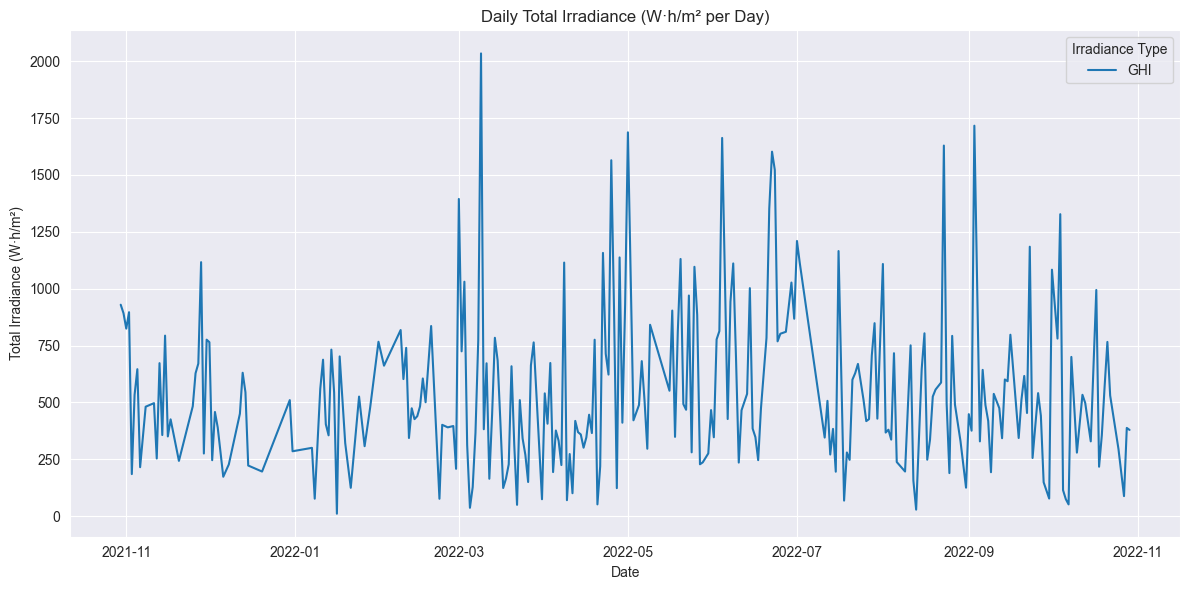

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Load the cleaned dataset ===
df = pd.read_csv("../cleaned/sierraleone-cleaned.csv")  # change for each country

# === Step 2: Convert Timestamp to datetime ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# === Step 3: Extract the date part only ===
df['Date'] = df['Timestamp'].dt.date

# === Step 4: Group by date and compute total daily irradiance ===
# If your data is in intervals (e.g., minutes), sum() approximates daily energy per m².
daily_irradiance = df.groupby('Date')[['GHI']].sum()

# === Step 5: Display summary stats ===
print("\n📊 Daily Irradiance Summary:")
print(daily_irradiance.describe())

# === Step 6: Plot daily total irradiance over time ===
daily_irradiance.plot(figsize=(12,6))
plt.title("Daily Total Irradiance (W·h/m² per Day)")
plt.xlabel("Date")
plt.ylabel("Total Irradiance (W·h/m²)")
plt.grid(True)
plt.legend(title="Irradiance Type")
plt.tight_layout()
plt.show()


💨 Daily Average WSgust Summary (m/s)
Minimum Daily Average: 0.00 m/s
Maximum Daily Average: 6.20 m/s
Overall Mean of Daily Averages: 1.13 m/s


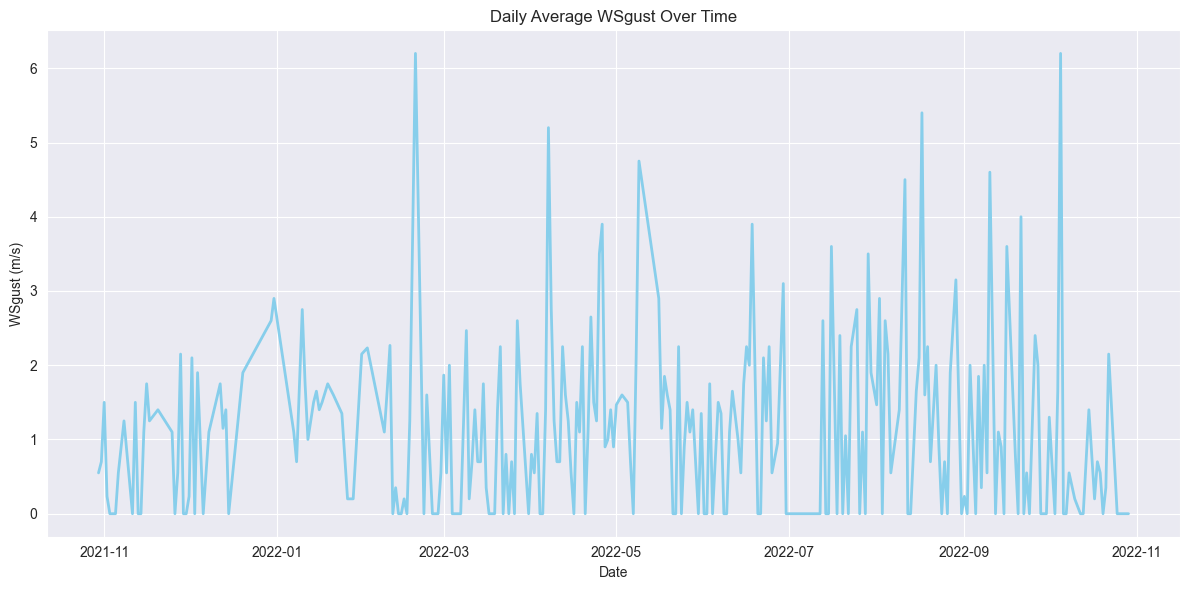

In [13]:
import pandas as pd

# === Step 1: Load the cleaned dataset ===
df = pd.read_csv("../cleaned/sierraleone-cleaned.csv")  # change for each country

# === Step 2: Convert Timestamp to datetime and extract date ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

# === Step 3: Compute the daily average WSgust ===
daily_avg_wsgust = df.groupby('Date')['WSgust'].mean()

# === Step 4: Calculate key statistics ===
min_avg = daily_avg_wsgust.min()
max_avg = daily_avg_wsgust.max()
mean_avg = daily_avg_wsgust.mean()

# === Step 5: Display results ===
print("💨 Daily Average WSgust Summary (m/s)")
print(f"Minimum Daily Average: {min_avg:.2f} m/s")
print(f"Maximum Daily Average: {max_avg:.2f} m/s")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} m/s")

# === Step 6 (Optional): Plot variation over time ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
daily_avg_wsgust.plot(color='skyblue', linewidth=2)
plt.title("Daily Average WSgust Over Time")
plt.xlabel("Date")
plt.ylabel("WSgust (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


## precipitation

In [5]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("../filtered/sierraleone-filtered.csv")

# Ensure Timestamp is datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Replace missing or negative precipitation values with 0 (if needed)
df['Precipitation'] = df['Precipitation'].clip(lower=0)

# Group by day and calculate daily average precipitation
daily_avg_precip = df.groupby(df['Timestamp'].dt.date)['Precipitation'].mean()

# Compute summary statistics
min_avg = daily_avg_precip.min()
max_avg = daily_avg_precip.max()
mean_avg = daily_avg_precip.mean()

# Print summary
print("Daily Average Precipitation Summary (mm)")
print(f"Minimum Daily Average: {min_avg:.2f} mm")
print(f"Maximum Daily Average: {max_avg:.2f} mm")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} mm")


Daily Average Precipitation Summary (mm)
Minimum Daily Average: 0.00 mm
Maximum Daily Average: 0.01 mm
Overall Mean of Daily Averages: 0.00 mm


## wind speed

In [ ]:
wind speed analysis

- Loads the cleaned dataset from "../cleaned/sierraleone-cleaned.csv".
- Parses the 'Timestamp' column as datetime to enable time-based grouping.
- Ensures wind speed ('WS') has no negative values by clipping values below 0 to 0.
- Groups the data by the date part of 'Timestamp' and computes the daily mean wind speed.
- Computes summary statistics on those daily averages: minimum, maximum, and overall mean.
- Prints the summary in m/s.

Assumptions and notes:
- The dataframe must contain 'Timestamp' and 'WS' columns.
- clip(lower=0) converts negative values to 0 but leaves NaNs unchanged; consider .fillna() if needed.
- Grouping uses df['Timestamp'].dt.date so results are indexed by plain Python dates.
"""

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your cleaned dataset (change path for each country)
df = pd.read_csv("../filtered/sierraleone-filtered.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Replace negatives or NaNs with 0
df['WS'] = df['WS'].clip(lower=0)

# Compute daily averages of wind speed
daily_avg_ws = df.groupby(df['Timestamp'].dt.date)['WS'].mean()

# Compute summary statistics
min_avg = daily_avg_ws.min()
max_avg = daily_avg_ws.max()
mean_avg = daily_avg_ws.mean()

# Print summary
print("Daily Average Wind Speed Summary (m/s)")
print(f"Minimum Daily Average: {min_avg:.2f} m/s")
print(f"Maximum Daily Average: {max_avg:.2f} m/s")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} m/s")


Daily Average Wind Speed Summary (m/s)
Minimum Daily Average: 0.00 m/s
Maximum Daily Average: 4.00 m/s
Overall Mean of Daily Averages: 1.75 m/s


## wind speed gust

💨 Daily Average WSgust Summary (m/s)
Minimum Daily Average: 0.00 m/s
Maximum Daily Average: 5.43 m/s
Overall Mean of Daily Averages: 2.55 m/s


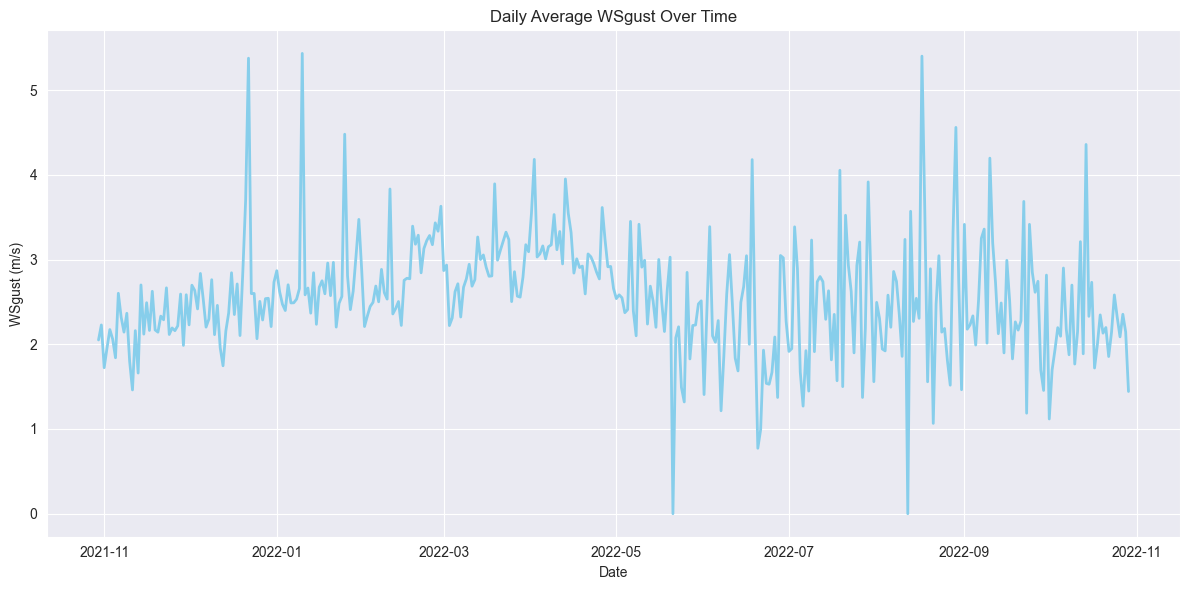

In [8]:
import pandas as pd

# === Step 1: Load the cleaned dataset ===
df = pd.read_csv("../filtered/sierraleone-filtered.csv")  # change for each country

# === Step 2: Convert Timestamp to datetime and extract date ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

# === Step 3: Compute the daily average WSgust ===
daily_avg_wsgust = df.groupby('Date')['WSgust'].mean()

# === Step 4: Calculate key statistics ===
min_avg = daily_avg_wsgust.min()
max_avg = daily_avg_wsgust.max()
mean_avg = daily_avg_wsgust.mean()

# === Step 5: Display results ===
print("💨 Daily Average WSgust Summary (m/s)")
print(f"Minimum Daily Average: {min_avg:.2f} m/s")
print(f"Maximum Daily Average: {max_avg:.2f} m/s")
print(f"Overall Mean of Daily Averages: {mean_avg:.2f} m/s")

# === Step 6 (Optional): Plot variation over time ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
daily_avg_wsgust.plot(color='skyblue', linewidth=2)
plt.title("Daily Average WSgust Over Time")
plt.xlabel("Date")
plt.ylabel("WSgust (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


## cleaned vs filtered 

C:\Users\hp\AppData\Local\Temp\ipykernel_12708\1577327730.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['confidence'] = np.where(filtered_df['Cleaning'] == 1, 1.0, 0.5)


Original data size: 525600
Filtered data size: 146012
Percentage retained: 27.78%


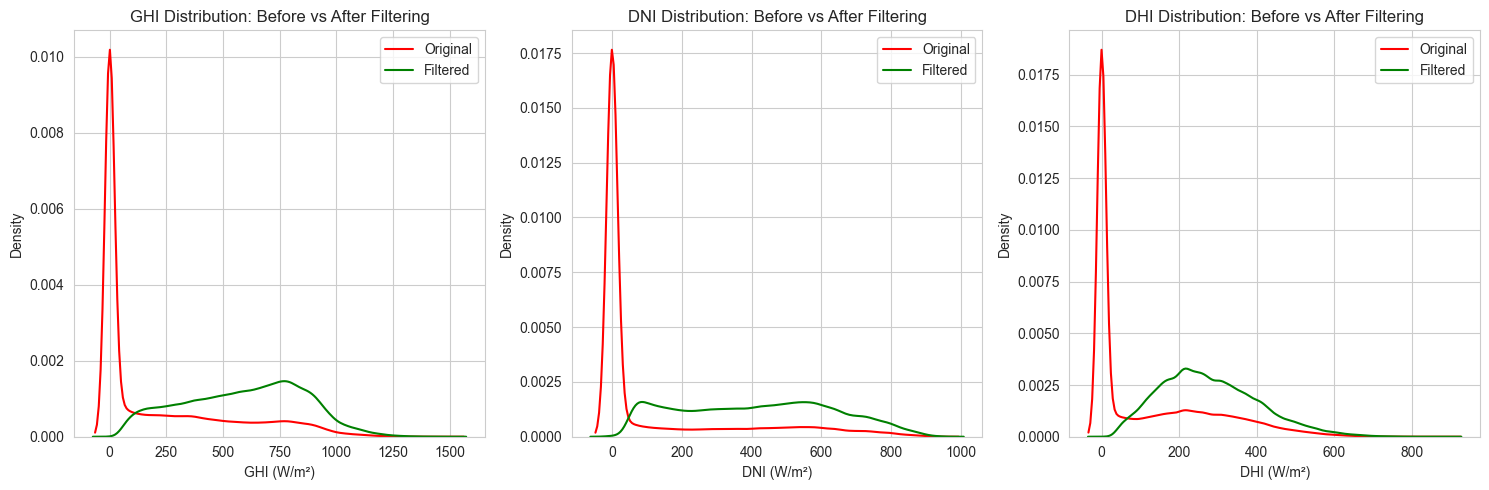

Filtered dataset saved to '../filtered/sierraleone-filtered.csv'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv("../data/sierraleone-bumbuna.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

irradiance_cols = ['GHI', 'DNI', 'DHI']

# Step 1: Replace negatives with zero
df[irradiance_cols] = df[irradiance_cols].clip(lower=0)

# Step 2: Mark "daytime" rows (approx 6 AM to 6 PM)
df['is_daylight'] = df['Hour'].between(6, 18)

# Step 3: Define a rule for "realistic" irradiance
df['realistic_irradiance'] = (
    (df['GHI'] > 50) &
    (df['DNI'] > 50) &
    (df['DHI'] >= 0)
)

# Step 4: Keep rows that are either:
# Cleaned (cleaning == 1)
# OR uncleaned but realistic and during daylight
filtered_df = df[
    (df['Cleaning'] == 1) |
    ((df['Cleaning'] == 0) & df['is_daylight'] & df['realistic_irradiance'])
]

# Step 5: Add a confidence weight column
filtered_df['confidence'] = np.where(filtered_df['Cleaning'] == 1, 1.0, 0.5)

# --- Summary statistics ---
print(f"Original data size: {len(df)}")
print(f"Filtered data size: {len(filtered_df)}")
print(f"Percentage retained: {len(filtered_df) / len(df) * 100:.2f}%")

# --- Visualization section ---
sns.set_style("whitegrid")
plt.figure(figsize=(15, 5))

for i, col in enumerate(irradiance_cols, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(df[col], label='Original', color='red', linewidth=1.5)
    sns.kdeplot(filtered_df[col], label='Filtered', color='green', linewidth=1.5)
    plt.title(f'{col} Distribution: Before vs After Filtering')
    plt.xlabel(f'{col} (W/m²)')
    plt.legend()

plt.tight_layout()
plt.show()

# --- Save filtered data ---
filtered_df.to_csv("../filtered/sierraleone-filtered.csv", index=False)
print("Filtered dataset saved to '../filtered/sierraleone-filtered.csv'")


## imputation
## filtered + no outliers

✅ Cleaned dataset shape: (144799, 23)

☀️ Average Irradiance Values (Cleaned Dataset):
GHI: 589.66 W/m²
DNI: 416.16 W/m²
DHI: 274.78 W/m²

📁 Saved summary averages to: ../filtered/sierraleone-irradiance-summary.csv


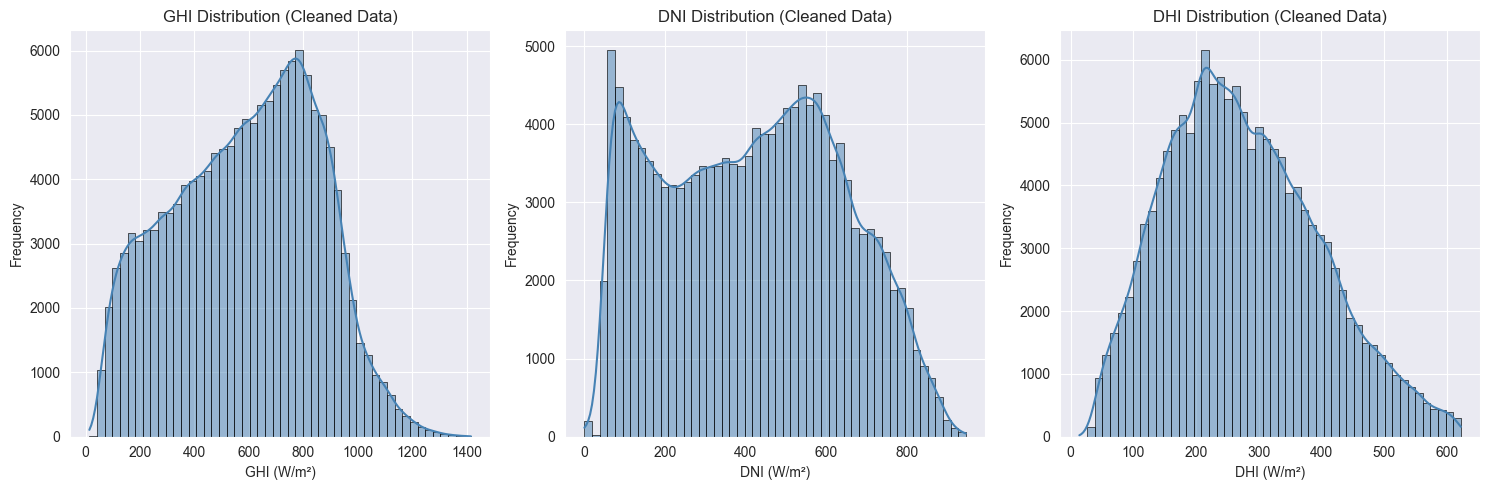

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Step 1: Load the cleaned dataset ===
input_path = "../filtered/sierraleone-filtered.csv"  # change this for each country
df = pd.read_csv(input_path)

# === Step 2: Convert Timestamp to datetime (if not already) ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# === Step 3: Select irradiance columns ===
irradiance_cols = ['GHI', 'DNI', 'DHI']

# === Step 4: Double-check no negative values remain ===
df[irradiance_cols] = df[irradiance_cols].clip(lower=0)

# === Step 5: Remove zeros (keep only daylight observations) ===
daylight_df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)].copy()

# === Step 6: Remove outliers using IQR ===
for col in irradiance_cols:
    Q1 = daylight_df[col].quantile(0.25)
    Q3 = daylight_df[col].quantile(0.75)
    IQR = Q3 - Q1
    daylight_df = daylight_df[
        (daylight_df[col] >= Q1 - 1.5 * IQR) &
        (daylight_df[col] <= Q3 + 1.5 * IQR)
    ]

print(f"✅ Cleaned dataset shape: {daylight_df.shape}")

# === Step 7: Compute average irradiance values ===
mean_values = daylight_df[irradiance_cols].mean()
print("\n☀️ Average Irradiance Values (Cleaned Dataset):")
for col, val in mean_values.items():
    print(f"{col}: {val:.2f} W/m²")

# === Optional: Save the averages to a summary file ===
summary_path = "../filtered/sierraleone-irradiance-summary.csv"
pd.DataFrame(mean_values, columns=['Average (W/m²)']).to_csv(summary_path)
print(f"\n📁 Saved summary averages to: {summary_path}")

# === Step 8: Plot histograms ===
sns.set_style('darkgrid')
plt.figure(figsize=(15, 5))

for i, col in enumerate(irradiance_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(daylight_df[col], bins=50, kde=True, color='steelblue', edgecolor='black')
    plt.title(f'{col} Distribution (Cleaned Data)')
    plt.xlabel(f'{col} (W/m²)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


## when irradiance variables are high acros the day

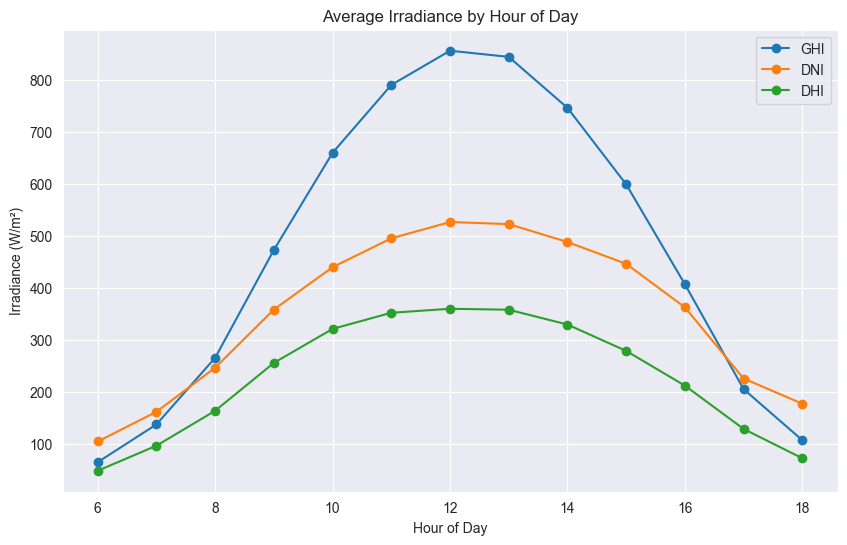

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../filtered/sierraleone-filtered.csv") 

# Convert timestamp to datetime and extract hour
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

# Compute average irradiance per hour
hourly_mean = df.groupby('Hour')[['GHI', 'DNI', 'DHI']].mean()

# Plot
hourly_mean.plot(kind='line', figsize=(10,6), marker='o')
plt.title("Average Irradiance by Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.xlabel("Hour of Day")
plt.grid(True)
plt.show()

## correlation between irradiance variables, precipitation and wind speed 

🔍 Correlation Matrix (Positive Irradiance Only):

                    GHI       DNI       DHI        WS  Precipitation      Tamb
GHI            1.000000  0.716968  0.614304  0.191163      -0.010330  0.273595
DNI            0.716968  1.000000 -0.060183  0.116768      -0.018705  0.235844
DHI            0.614304 -0.060183  1.000000  0.126360       0.003932  0.089532
WS             0.191163  0.116768  0.126360  1.000000      -0.003574  0.537417
Precipitation -0.010330 -0.018705  0.003932 -0.003574       1.000000 -0.010442
Tamb           0.273595  0.235844  0.089532  0.537417      -0.010442  1.000000


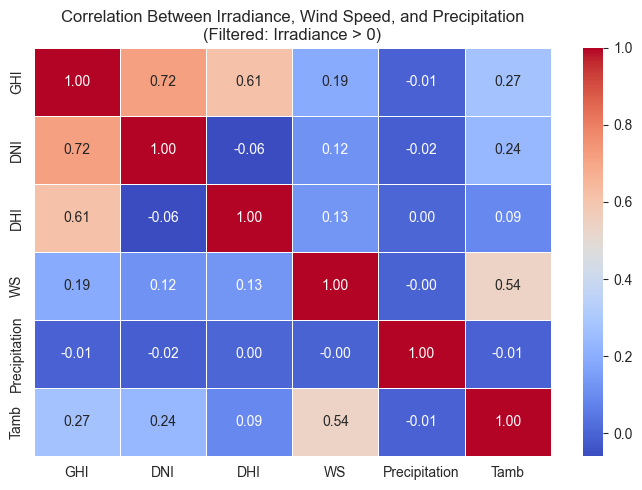

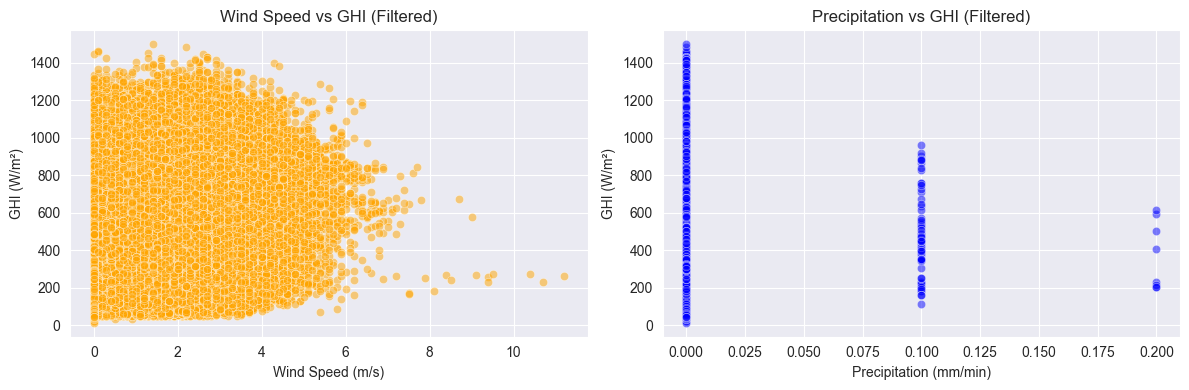

In [11]:
# --- Correlation Between Irradiance, Wind Speed, and Precipitation (Filtered) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load and prepare data
df = pd.read_csv("../filtered/sierraleone-filtered.csv")

# 2️⃣ Keep relevant columns
cols = ['GHI', 'DNI', 'DHI', 'WS', 'Precipitation', 'Tamb']
df = df[cols]

# 3️⃣ Remove rows where any irradiance value (GHI, DNI, DHI) <= 0
df = df[(df['GHI'] > 0) & (df['DNI'] > 0) & (df['DHI'] > 0)]

# 4️⃣ Compute correlation matrix
corr = df.corr()

# 5️⃣ Display correlation values
print("🔍 Correlation Matrix (Positive Irradiance Only):\n")
print(corr)

# 6️⃣ Plot correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Irradiance, Wind Speed, and Precipitation\n(Filtered: Irradiance > 0)')
plt.tight_layout()
plt.show()

# 7️⃣ Scatter plots to visualize relationships
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='WS', y='GHI', alpha=0.5, color='orange')
plt.title('Wind Speed vs GHI (Filtered)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m²)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Precipitation', y='GHI', alpha=0.5, color='blue')
plt.title('Precipitation vs GHI (Filtered)')
plt.xlabel('Precipitation (mm/min)')
plt.ylabel('GHI (W/m²)')

plt.tight_layout()
plt.show()

